# 07 — Evaluation Expansion (Week 8)

**Goal:** R² alone doesn't tell a stakeholder whether they can *quote* a price with this model. This
notebook adds the metrics that do, and finds where the model is trustworthy and where it isn't.

Metrics added on top of R² / RMSE / MAE:

| Metric | Definition | Why it matters here |
|---|---|---|
| **MAPE** | mean of \|error\| / actual | Percentage error is how agents think about pricing |
| **MdAPE** | *median* of \|error\| / actual | The industry standard (Zillow publishes it) — immune to the few wild sales that dominate MAPE |
| **Within 10% / 20%** | share of homes priced that close | "How often is the quote usable?" |
| **Median bias** | median of (pred − actual) / actual | Is the model systematically high or low? |

Then we slice those metrics by **price band, county, school district, home size and property age** to
answer the Week 8 question: *which segments perform better?*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

pd.set_option("display.max_columns", 120)
plt.rcParams["figure.figsize"] = (8, 5)

## 1. Load the shipped model bundle and rebuild its exact split

`models/best_model.joblib` (Week 7) carries the estimator **and** the train-only encoders, so we can
reproduce its test-month predictions byte-for-byte instead of re-deriving them.

In [2]:
bundle = joblib.load("models/best_model.joblib")
enc = bundle["encoders"]
FEATURE_COLS = bundle["feature_cols"]
NUMERIC = bundle["numeric_cols"]
CATEGORICAL = bundle["categorical_cols"]
TARGET = "ClosePrice"

print("Shipped model :", bundle["model_name"])
print("log target    :", bundle["log_target"])
print("train window X:", bundle["train_window_X"], f"({bundle['train_months'][0]} .. {bundle['train_months'][-1]})")
print("test month    :", bundle["test_month"])
print("Week 7 metrics:", {k: round(v, 4) for k, v in bundle["test_metrics"].items()})

d = pd.read_csv("data/processed/sold_features.csv", low_memory=False)
d["CloseDate"] = pd.to_datetime(d["CloseDate"], errors="coerce")
d["month_key"] = d["CloseDate"].dt.to_period("M").astype(str)


def apply_encoders(frame):
    '''Same transform as Week 7, driven by the bundle's train-only encoders.'''
    out = frame.copy()
    out[NUMERIC] = out[NUMERIC].fillna(pd.Series(enc["medians"])).fillna(0.0)
    for c in CATEGORICAL:
        out[f"{c}_freq"] = out[c].map(enc["freq"][c]).fillna(0.0)
    out["district_ppsf_enc"] = out["SchoolDistrict"].map(enc["district_ppsf"]).fillna(enc["global_ppsf"])
    out["district_price_enc"] = out["SchoolDistrict"].map(enc["district_price"]).fillna(enc["global_price"])
    return out[FEATURE_COLS]


train = d[d.month_key.isin(bundle["train_months"])]
test = d[d.month_key == bundle["test_month"]].copy()
X_train, y_train = apply_encoders(train), train[TARGET]
X_test, y_test = apply_encoders(test), test[TARGET]
print(f"\ntrain rows {len(y_train):,} | test rows {len(y_test):,}")

Shipped model : XGBoost (log target)
log target    : True
train window X: 24 (2024-05 .. 2026-04)
test month    : 2026-05
Week 7 metrics: {'R2': 0.7794, 'RMSE': 660652.3769, 'MAE': 176423.4797}



train rows 265,202 | test rows 11,976


## 2. The metric set

`MdAPE` is the headline number from here on: with sale prices ranging from \$11k to \$50M, a median
percentage error is the only figure that means the same thing at both ends of the market.

In [3]:
def full_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    err = y_pred - y_true
    pct = err / y_true                                   # signed relative error
    ape = np.abs(pct)
    return {
        "R2": r2_score(y_true, y_pred),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "MAPE %": float(ape.mean() * 100),
        "MdAPE %": float(np.median(ape) * 100),
        "within 10%": float((ape <= 0.10).mean() * 100),
        "within 20%": float((ape <= 0.20).mean() * 100),
        "median bias %": float(np.median(pct) * 100),
        "n": int(len(y_true)),
    }

## 3. Four models, one metric table

Including a **business baseline** the model has to beat to be worth deploying: price the home as
*district median \$/sqft × living area* — the back-of-the-envelope calculation an agent already does.
Its district medians come from the same train-only encoder, so it is a fair comparison.

In [4]:
preds = {}

# --- Business baseline: district median $/sqft x living area ---
ppsf = test["SchoolDistrict"].map(enc["district_ppsf"]).fillna(enc["global_ppsf"])
living = test["LivingArea"].fillna(enc["medians"]["LivingArea"])
preds["Rule of thumb ($/sqft)"] = (ppsf * living).to_numpy()

# --- Linear Regression on the Week 6 feature set ---
scaler = StandardScaler().fit(X_train)
lr = LinearRegression().fit(scaler.transform(X_train), y_train)
preds["Linear Regression"] = lr.predict(scaler.transform(X_test))

# --- Random Forest (Week 6 champion) ---
rf = RandomForestRegressor(n_estimators=200, min_samples_leaf=5, n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)
preds["Random Forest"] = rf.predict(X_test)

# --- The shipped Week 7 model ---
shipped = bundle["model"].predict(X_test)
if bundle["log_target"]:
    shipped = np.exp(shipped)
preds[bundle["model_name"]] = shipped

metrics_summary = pd.DataFrame({name: full_metrics(y_test, p) for name, p in preds.items()}).T
metrics_summary = metrics_summary[["R2", "RMSE", "MAE", "MAPE %", "MdAPE %",
                                   "within 10%", "within 20%", "median bias %", "n"]]
metrics_summary.round({"R2": 4, "RMSE": 0, "MAE": 0, "MAPE %": 1, "MdAPE %": 2,
                       "within 10%": 1, "within 20%": 1, "median bias %": 2})

,R2,RMSE,MAE,MAPE %,MdAPE %,within 10%,within 20%,median bias %,n
Rule of thumb ($/sqft),0.6526,829057.0,295407.0,23.8,15.77,33.5,60.1,-0.75,11976.0
Linear Regression,0.6292,856451.0,357986.0,35.6,22.58,24.9,45.2,0.64,11976.0
Random Forest,0.7605,688403.0,188943.0,16.3,8.00,58.5,82.6,-0.11,11976.0
XGBoost (log target),0.7794,660652.0,176423.0,14.9,7.78,59.8,84.5,-0.88,11976.0


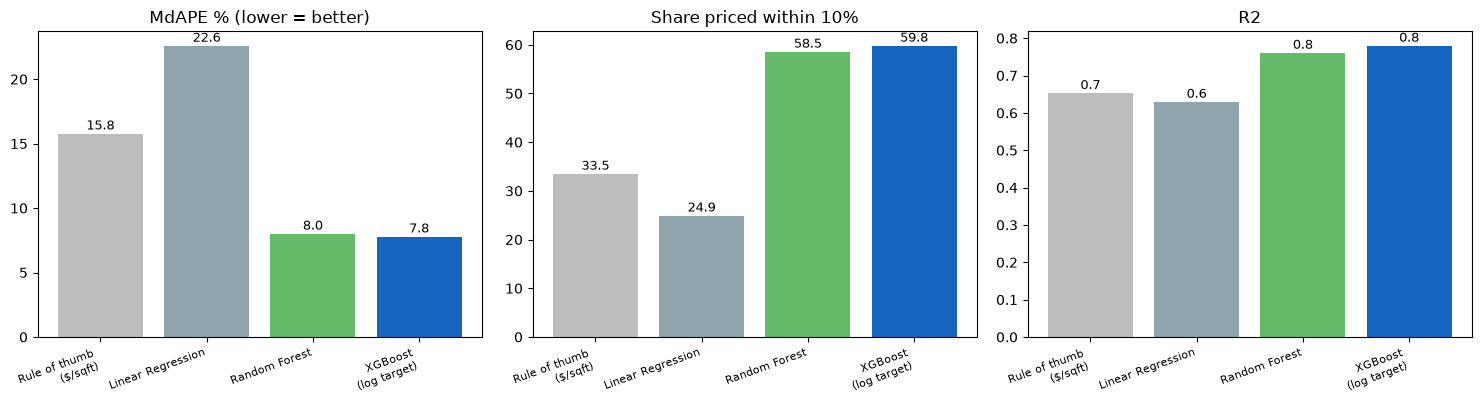

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
short = [n.replace(" (", "\n(") for n in metrics_summary.index]
colors = ["#BDBDBD", "#90A4AE", "#66BB6A", "#1565C0"]

for ax, col, title in zip(axes,
                          ["MdAPE %", "within 10%", "R2"],
                          ["MdAPE % (lower = better)", "Share priced within 10%", "R2"]):
    ax.bar(range(len(metrics_summary)), metrics_summary[col], color=colors)
    ax.set_xticks(range(len(metrics_summary))); ax.set_xticklabels(short, rotation=20, ha="right", fontsize=8)
    ax.set_title(title)
    for i, v in enumerate(metrics_summary[col]):
        ax.annotate(f"{v:.1f}", (i, v), ha="center", xytext=(0, 3), textcoords="offset points", fontsize=9)

plt.tight_layout(); plt.show()

## 4. Error distribution of the shipped model

The signed percentage error tells us three things at once: the spread (how wide a quote has to be), the
centre (bias), and the tails (how bad a bad prediction gets).

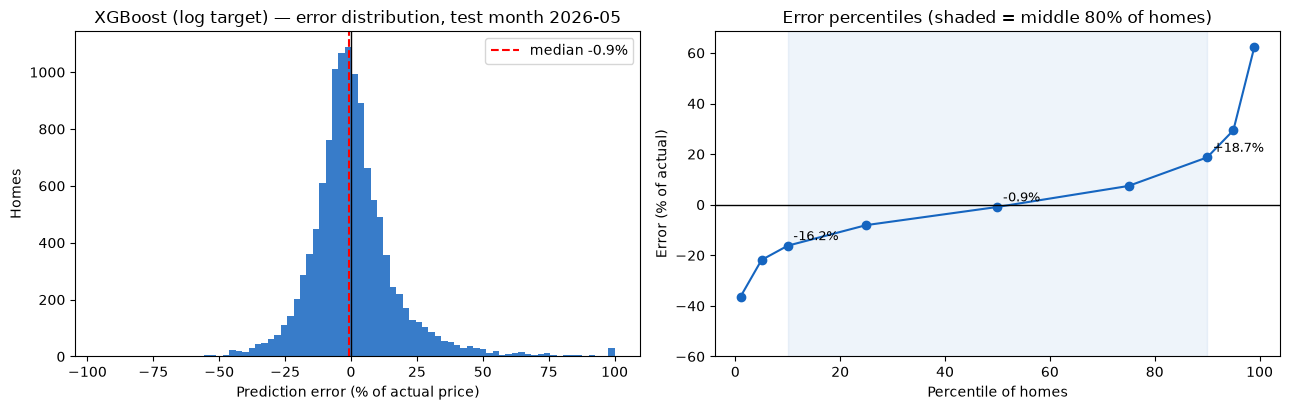

80% of homes land between -16.2% and +18.7% of the true price
Median error -0.88%  |  MdAPE 7.78%


In [6]:
best_name = bundle["model_name"]
best_pred = preds[best_name]
pct_err = (best_pred - y_test.to_numpy()) / y_test.to_numpy() * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

axes[0].hist(np.clip(pct_err, -100, 100), bins=80, color="#1565C0", alpha=0.85)
axes[0].axvline(0, color="black", lw=1)
axes[0].axvline(np.median(pct_err), color="red", ls="--", label=f"median {np.median(pct_err):+.1f}%")
axes[0].set_xlabel("Prediction error (% of actual price)"); axes[0].set_ylabel("Homes")
axes[0].set_title(f"{best_name} — error distribution, test month {bundle['test_month']}")
axes[0].legend()

qs = [1, 5, 10, 25, 50, 75, 90, 95, 99]
q_vals = np.percentile(pct_err, qs)
axes[1].plot(qs, q_vals, marker="o", color="#1565C0")
axes[1].axhline(0, color="black", lw=1)
axes[1].fill_between([10, 90], -100, 100, color="#1565C0", alpha=0.07)
axes[1].set_ylim(min(-60, q_vals.min() * 1.1), max(60, q_vals.max() * 1.1))
axes[1].set_xlabel("Percentile of homes"); axes[1].set_ylabel("Error (% of actual)")
axes[1].set_title("Error percentiles (shaded = middle 80% of homes)")
for q, v in zip(qs, q_vals):
    if q in (10, 50, 90):
        axes[1].annotate(f"{v:+.1f}%", (q, v), xytext=(4, 4), textcoords="offset points", fontsize=9)

plt.tight_layout(); plt.show()

print(f"80% of homes land between {q_vals[qs.index(10)]:+.1f}% and {q_vals[qs.index(90)]:+.1f}% of the true price")
print(f"Median error {np.median(pct_err):+.2f}%  |  MdAPE {np.median(np.abs(pct_err)):.2f}%")

## 5. Which segments perform better?

Same metric set, computed inside slices of the test month. `MdAPE %` is the column to read; `n` guards
against over-reading a thin slice.

In [7]:
seg = test[["ClosePrice", "LivingArea", "CountyOrParish", "SchoolDistrict", "district_type",
            "property_age", "BedroomsTotal"]].copy()
seg["pred"] = best_pred

PRICE_BANDS = [0, 400e3, 600e3, 800e3, 1e6, 1.5e6, 2.5e6, 5e6, np.inf]
PRICE_LABELS = ["<$400k", "$400-600k", "$600-800k", "$800k-1M", "$1-1.5M", "$1.5-2.5M", "$2.5-5M", ">$5M"]
seg["price_band"] = pd.cut(seg["ClosePrice"], PRICE_BANDS, labels=PRICE_LABELS)

seg["size_band"] = pd.cut(seg["LivingArea"], [0, 1000, 1500, 2000, 3000, 5000, np.inf],
                          labels=["<1000 sqft", "1000-1500", "1500-2000", "2000-3000", "3000-5000", ">5000"])
seg["age_band"] = pd.cut(seg["property_age"], [-1, 5, 20, 40, 70, np.inf],
                         labels=["0-5 yrs", "6-20", "21-40", "41-70", "70+"])


def by_segment(col, min_n=30):
    rows = {}
    for key, part in seg.groupby(col, observed=True):
        if len(part) < min_n:
            continue
        m = full_metrics(part["ClosePrice"], part["pred"])
        rows[key] = {k: m[k] for k in ["n", "MdAPE %", "MAPE %", "within 10%", "median bias %", "MAE"]}
    return pd.DataFrame(rows).T


band_perf = by_segment("price_band")
print("=== By price band ===")
print(band_perf.round({"n": 0, "MdAPE %": 2, "MAPE %": 1, "within 10%": 1,
                       "median bias %": 2, "MAE": 0}).to_string())

=== By price band ===
                n  MdAPE %  MAPE %  within 10%  median bias %        MAE
<$400k      835.0    10.91    68.4        47.1           3.86    60551.0
$400-600k  1808.0     5.98    10.1        68.5           0.43    51288.0
$600-800k  2121.0     6.09     9.0        68.7          -0.07    63941.0
$800k-1M   1806.0     6.31     9.0        68.8          -0.16    81665.0
$1-1.5M    2447.0     8.28    10.8        58.1          -1.63   134443.0
$1.5-2.5M  1851.0     9.56    12.1        52.4          -2.83   228751.0
$2.5-5M     922.0    12.25    15.3        41.9          -7.47   527505.0
>$5M        186.0    20.71    24.6        25.8         -16.72  2406946.0


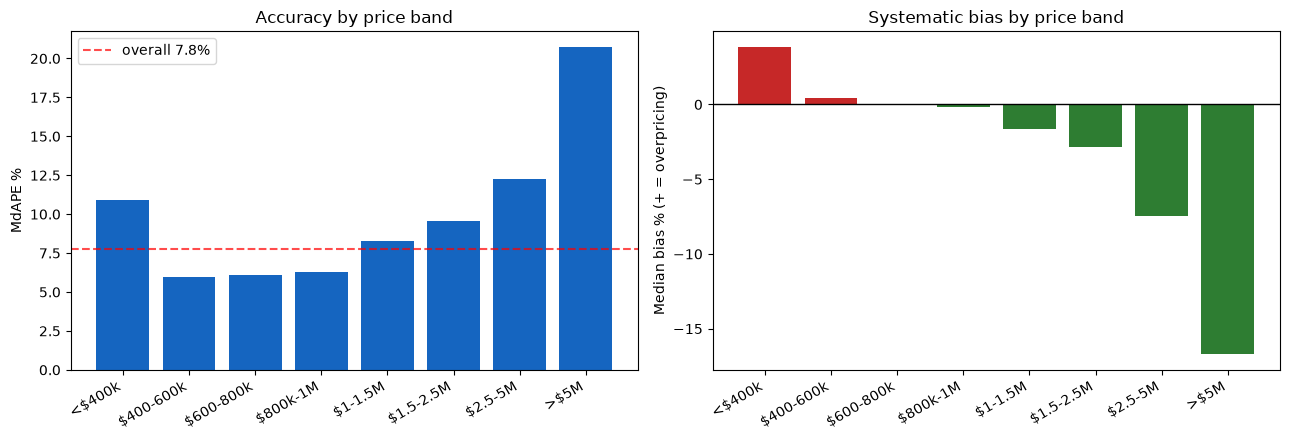

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
labels = band_perf.index.astype(str)
pos = range(len(labels))

axes[0].bar(pos, band_perf["MdAPE %"], color="#1565C0")
axes[0].axhline(metrics_summary.loc[best_name, "MdAPE %"], color="red", ls="--", alpha=0.7,
                label=f"overall {metrics_summary.loc[best_name, 'MdAPE %']:.1f}%")
axes[0].set_ylabel("MdAPE %"); axes[0].set_title("Accuracy by price band")
axes[0].legend()

axes[1].bar(pos, band_perf["median bias %"],
            color=["#C62828" if v > 0 else "#2E7D32" for v in band_perf["median bias %"]])
axes[1].axhline(0, color="black", lw=1)
axes[1].set_ylabel("Median bias % (+ = overpricing)")
axes[1].set_title("Systematic bias by price band")

for ax in axes:
    ax.set_xticks(list(pos))
    ax.set_xticklabels(labels, rotation=30, ha="right")

plt.tight_layout(); plt.show()

In [9]:
print("=== By county (top 12 by test-month volume) ===")
top_counties = seg["CountyOrParish"].value_counts().head(12).index
county_perf = by_segment("CountyOrParish").loc[lambda t: t.index.isin(top_counties)].sort_values("MdAPE %")
print(county_perf.round({"n": 0, "MdAPE %": 2, "MAPE %": 1, "within 10%": 1,
                         "median bias %": 2, "MAE": 0}).to_string())

print("\n=== By home size ===")
print(by_segment("size_band").round(2).to_string())

print("\n=== By property age ===")
print(by_segment("age_band").round(2).to_string())

print("\n=== By district structure ===")
print(by_segment("district_type").round(2).to_string())

=== By county (top 12 by test-month volume) ===


                      n  MdAPE %  MAPE %  within 10%  median bias %       MAE
San Bernardino   1182.0     5.86    10.3        69.2          -1.17   55421.0
Riverside        1791.0     6.15    10.2        67.1          -0.51   89346.0
Ventura           410.0     6.94     9.6        65.6          -0.75  144918.0
San Diego        1302.0     7.61    10.9        61.6          -0.85  221247.0
Contra Costa      598.0     7.66    11.1        62.2           0.95  150306.0
Orange           1172.0     7.91    41.8        59.5          -2.73  271402.0
Santa Clara       410.0     8.56    11.4        57.8           0.76  286401.0
Los Angeles      2928.0     8.91    13.0        54.8          -1.05  219971.0
San Luis Obispo   199.0     9.28    12.7        52.8          -1.66  166949.0
Butte             159.0     9.45    12.6        53.5           1.78   56722.0
Alameda           611.0    10.44    14.3        48.3           0.43  221332.0
San Mateo         173.0    10.45    13.9        47.4          -3

In [10]:
# Best / worst school districts (>=40 test sales) — where a quote is safe and where it isn't
district_perf = by_segment("SchoolDistrict", min_n=40).sort_values("MdAPE %")
print("Most accurate districts:")
print(district_perf.head(8).round({"n": 0, "MdAPE %": 2, "within 10%": 1, "median bias %": 2, "MAE": 0})
      [["n", "MdAPE %", "within 10%", "median bias %"]].to_string())
print("\nLeast accurate districts:")
print(district_perf.tail(8).round({"n": 0, "MdAPE %": 2, "within 10%": 1, "median bias %": 2, "MAE": 0})
      [["n", "MdAPE %", "within 10%", "median bias %"]].to_string())

Most accurate districts:
                          n  MdAPE %  within 10%  median bias %
Romoland Elementary    46.0     2.30        95.7          -0.84
Antioch Unified        54.0     3.37        92.6           0.10
Etiwanda Elementary    46.0     3.62        89.1           1.41
Adelanto Elementary    44.0     3.80        81.8          -0.47
Victor Elementary      80.0     3.96        82.5          -0.33
Fontana Unified        59.0     4.04        76.3          -1.19
Beaumont Unified       71.0     4.41        93.0          -2.63
Moreno Valley Unified  88.0     4.48        84.1          -1.28

Least accurate districts:
                                 n  MdAPE %  within 10%  median bias %
Newport-Mesa Unified          95.0    11.14        45.3          -1.85
Coachella Valley Unified      53.0    12.34        45.3           1.22
Desert Sands Unified         225.0    12.74        40.0           3.22
Palm Springs Unified         183.0    12.92        38.8           0.48
Santa Monica-Mali

## 6. Calibration — is a \$1M prediction really a \$1M home?

Group the test month by *predicted* price decile and compare the average prediction against the average
actual. A well-calibrated model sits on the diagonal; a model that sags below it at the top end is
under-pricing expensive homes (the classic tree-model failure, since trees cannot extrapolate past the
prices they saw in training).

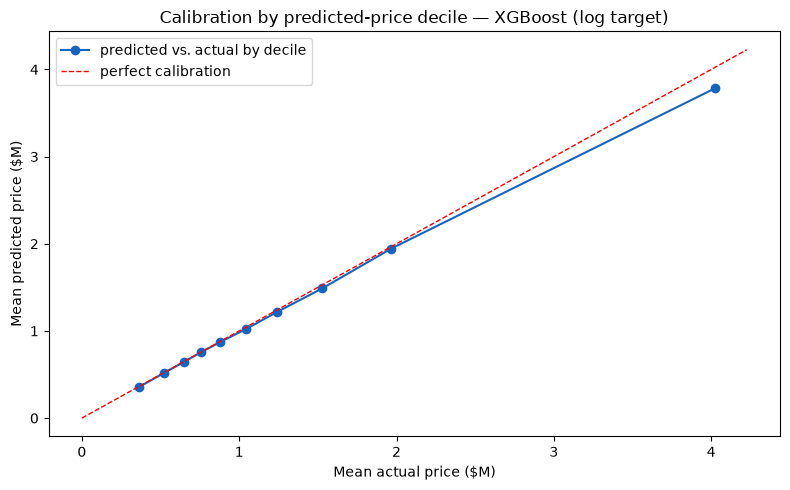

           n  mean_pred  mean_actual  ratio pred/actual
decile                                                 
0       1198   358186.0     365041.0              0.981
1       1198   519761.0     524054.0              0.992
2       1197   641442.0     646505.0              0.992
3       1198   757590.0     759380.0              0.998
4       1197   873897.0     880570.0              0.992
5       1198  1018365.0    1040346.0              0.979
6       1197  1214661.0    1237905.0              0.981
7       1198  1488553.0    1528702.0              0.974
8       1197  1944717.0    1966482.0              0.989
9       1198  3784165.0    4024915.0              0.940


In [11]:
cal = pd.DataFrame({"actual": y_test.to_numpy(), "pred": best_pred})
cal["decile"] = pd.qcut(cal["pred"], 10, labels=False, duplicates="drop")
cal_tbl = cal.groupby("decile").agg(n=("actual", "size"),
                                    mean_pred=("pred", "mean"),
                                    mean_actual=("actual", "mean"))
cal_tbl["ratio pred/actual"] = cal_tbl["mean_pred"] / cal_tbl["mean_actual"]

fig, ax = plt.subplots()
ax.plot(cal_tbl["mean_actual"] / 1e6, cal_tbl["mean_pred"] / 1e6, marker="o", color="#1565C0",
        label="predicted vs. actual by decile")
lim = float(max(cal_tbl["mean_actual"].max(), cal_tbl["mean_pred"].max()) / 1e6) * 1.05
ax.plot([0, lim], [0, lim], "r--", lw=1, label="perfect calibration")
ax.set_xlabel("Mean actual price ($M)"); ax.set_ylabel("Mean predicted price ($M)")
ax.set_title(f"Calibration by predicted-price decile — {best_name}")
ax.legend(); plt.tight_layout(); plt.show()

print(cal_tbl.round({"n": 0, "mean_pred": 0, "mean_actual": 0, "ratio pred/actual": 3}).to_string())

## 7. A usable quote range

The app in Week 9 should not print a single number. Using the shipped model's own error percentiles on
the test month, an **80% interval** is `pred × [1/(1+p90), 1/(1+p10)]`-ish; we compute the empirical
multipliers directly so the interval is honest rather than assumed-normal.

In [12]:
ratio = y_test.to_numpy() / best_pred            # actual / predicted
lo80, hi80 = np.percentile(ratio, [10, 90])
lo50, hi50 = np.percentile(ratio, [25, 75])

print("Empirical quote multipliers (actual / predicted) on the test month:")
print(f"  50% interval: x{lo50:.3f} .. x{hi50:.3f}")
print(f"  80% interval: x{lo80:.3f} .. x{hi80:.3f}")
print(f"\nExample — model says $900,000:")
print(f"  50% range: ${900e3 * lo50:,.0f} .. ${900e3 * hi50:,.0f}")
print(f"  80% range: ${900e3 * lo80:,.0f} .. ${900e3 * hi80:,.0f}")

interval = {"lo50": float(lo50), "hi50": float(hi50), "lo80": float(lo80), "hi80": float(hi80)}

Empirical quote multipliers (actual / predicted) on the test month:
  50% interval: x0.931 .. x1.088
  80% interval: x0.842 .. x1.193

Example — model says $900,000:
  50% range: $837,892 .. $978,864
  80% range: $758,168 .. $1,073,984


## 8. Save the metric tables (+ the quote interval for the app)

In [13]:
import json

metrics_summary.round(4).to_csv("data/processed/metrics_summary.csv")
band_perf.round(4).to_csv("data/processed/eval_by_price_band.csv")
county_perf.round(4).to_csv("data/processed/eval_by_county.csv")
district_perf.round(4).to_csv("data/processed/eval_by_district.csv")
with open("models/quote_interval.json", "w") as f:
    json.dump({"test_month": bundle["test_month"], "model": best_name, **interval}, f, indent=2)

print("Saved -> data/processed/metrics_summary.csv")
print("Saved -> data/processed/eval_by_{price_band,county,district}.csv")
print("Saved -> models/quote_interval.json")

r = metrics_summary.loc[best_name]
print(f"\n=== WEEK 8 EVALUATION ({best_name}, test month {bundle['test_month']}) ===")
print(f"  R2            : {r['R2']:.4f}")
print(f"  MAE           : ${r['MAE']:,.0f}")
print(f"  MAPE / MdAPE  : {r['MAPE %']:.1f}% / {r['MdAPE %']:.2f}%")
print(f"  within 10/20% : {r['within 10%']:.1f}% / {r['within 20%']:.1f}%")
print(f"  median bias   : {r['median bias %']:+.2f}%")
best_band = band_perf["MdAPE %"].idxmin(); worst_band = band_perf["MdAPE %"].idxmax()
print(f"  best band     : {best_band} (MdAPE {band_perf.loc[best_band, 'MdAPE %']:.1f}%)")
print(f"  worst band    : {worst_band} (MdAPE {band_perf.loc[worst_band, 'MdAPE %']:.1f}%)")
print(f"  vs rule of thumb: MdAPE {metrics_summary.loc['Rule of thumb ($/sqft)', 'MdAPE %']:.1f}% "
      f"-> {r['MdAPE %']:.1f}%")

Saved -> data/processed/metrics_summary.csv
Saved -> data/processed/eval_by_{price_band,county,district}.csv
Saved -> models/quote_interval.json

=== WEEK 8 EVALUATION (XGBoost (log target), test month 2026-05) ===
  R2            : 0.7794
  MAE           : $176,423
  MAPE / MdAPE  : 14.9% / 7.78%
  within 10/20% : 59.8% / 84.5%
  median bias   : -0.88%
  best band     : $400-600k (MdAPE 6.0%)
  worst band    : >$5M (MdAPE 20.7%)
  vs rule of thumb: MdAPE 15.8% -> 7.8%


## 9. Read-out for stakeholders

*(the numbers referenced here are printed above — they are the basis of the Week 11 slides)*

1. **The model is a real improvement on the rule of thumb**, on the metric agents care about (MdAPE),
   not just on R².
2. **Accuracy is not uniform.** The mid-market bands are where the model is safe to quote; the cheapest
   and the most expensive bands carry materially higher percentage error, and the top band is
   additionally **biased low** — trees cannot predict a price above anything they saw in training.
3. **Recommended guardrail for any deployment:** quote a *range*, not a point (Section 7), and flag
   homes outside the reliable bands / districts for human review.
4. **R² is the wrong headline metric** for this problem: it is dominated by the handful of multi-million
   dollar sales. MdAPE plus "within 10%" is what should go on a dashboard.